(-0.5, 950.5, 636.5, -0.5)

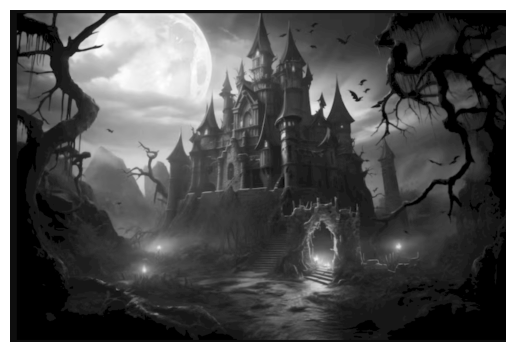

In [3]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
image = cv2.imread(r"C:\Users\shema\OneDrive\Desktop\hc1.png",	0)
plt.imshow( image , cmap='gray')
plt.axis("off")

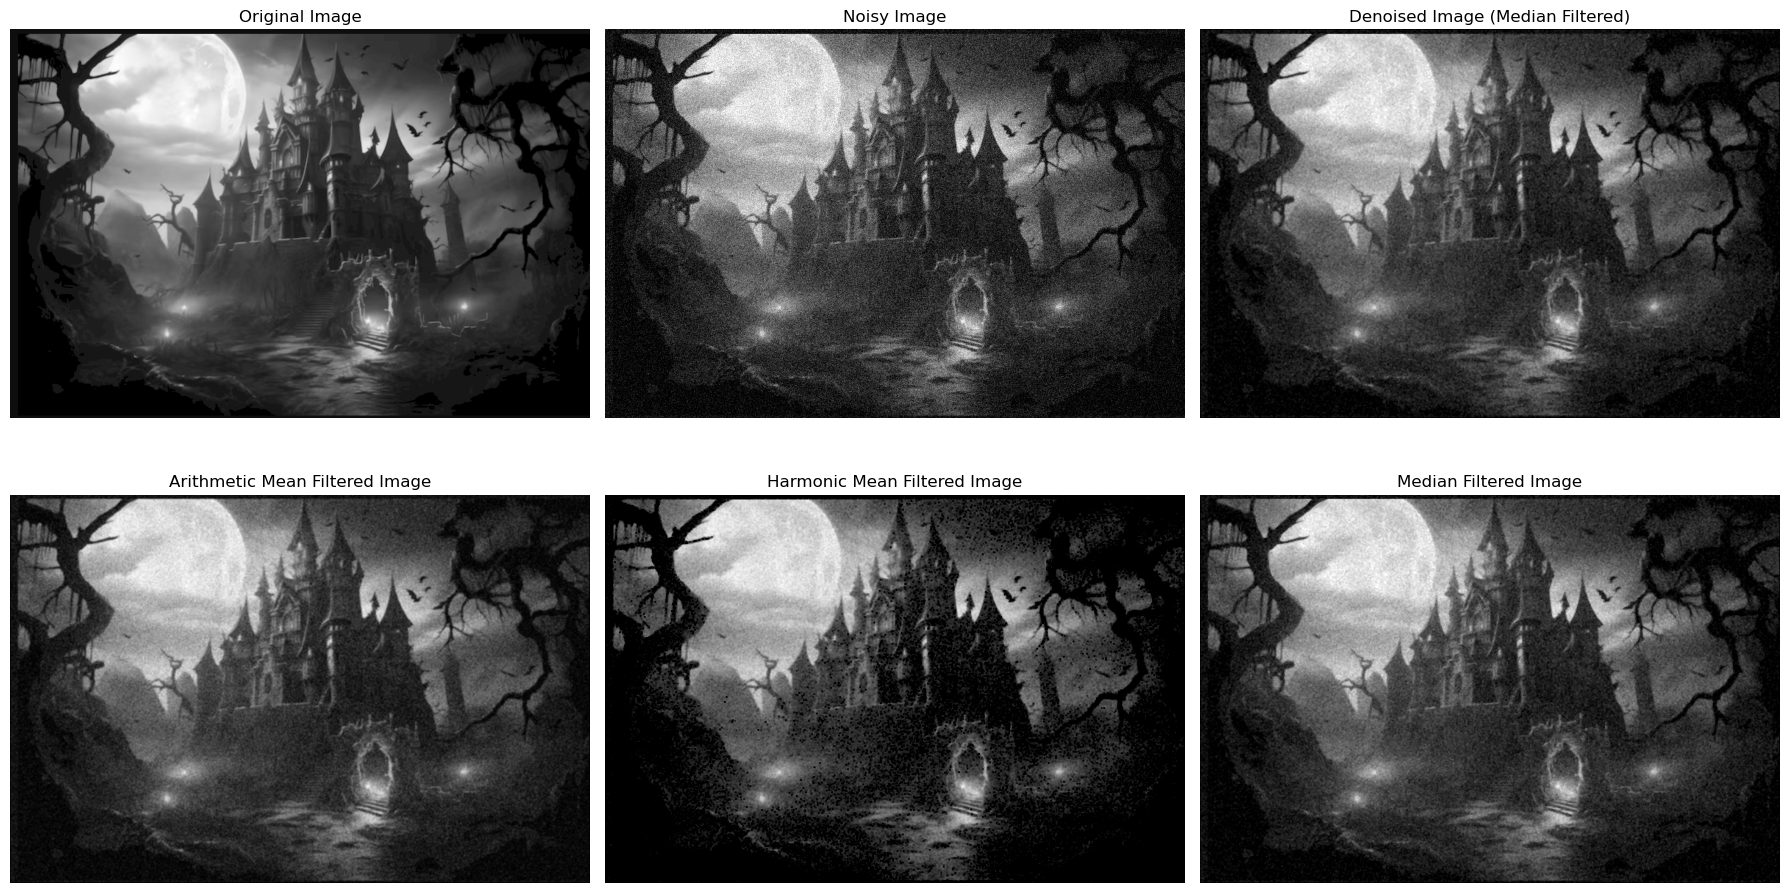

In [57]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the image in grayscale
image = cv2.imread(r"C:\Users\shema\OneDrive\Desktop\hc1.png", cv2.IMREAD_GRAYSCALE)

def add_gaussian_noise(image, mean=0, sigma=25):
    rows, cols = image.shape 
    gauss = np.random.normal(mean, sigma, (rows, cols))
    noisy_image = np.uint8(np.clip(image + gauss, 0, 255))
    return noisy_image
noisy_image = add_gaussian_noise(image)
kernel_size = 3
kernel_radius = kernel_size // 2
height, width = image.shape
mean_filtered_image = np.zeros_like(image)
for x in range(kernel_radius, height - kernel_radius):
    for y in range(kernel_radius, width - kernel_radius):
        neighborhood = noisy_image[x - kernel_radius: x + kernel_radius + 1, y - kernel_radius: y + kernel_radius + 1]
        mean_value = np.mean(neighborhood)
        mean_filtered_image[x, y] = mean_value
harmonic_filtered_image = np.zeros_like(image)
for x in range(kernel_radius, height - kernel_radius):
    for y in range(kernel_radius, width - kernel_radius):
        neighborhood = noisy_image[x - kernel_radius: x + kernel_radius + 1, y - kernel_radius: y + kernel_radius + 1]
        reciprocal_sum = np.sum(1.0 / (neighborhood + 1e-5)) 
        harmonic_mean_value = 9.0 / reciprocal_sum
        harmonic_filtered_image[x, y] = harmonic_mean_value
median_filtered_image = np.zeros_like(image)
for x in range(kernel_radius, height - kernel_radius):
    for y in range(kernel_radius, width - kernel_radius):
        neighborhood = noisy_image[x - kernel_radius: x + kernel_radius + 1, y - kernel_radius: y + kernel_radius + 1]
        flattened_neighborhood = neighborhood.flatten()
        flattened_neighborhood.sort()
        median_value = flattened_neighborhood[len(flattened_neighborhood) // 2]
        median_filtered_image[x, y] = median_value
plt.figure(figsize=(18, 10))
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(2, 3, 2)
plt.imshow(noisy_image, cmap='gray')
plt.title("Noisy Image")
plt.axis('off')
plt.subplot(2, 3, 3)
plt.imshow(median_filtered_image, cmap='gray')
plt.title("Denoised Image (Median Filtered)")
plt.axis('off')
plt.subplot(2, 3, 4)
plt.imshow(mean_filtered_image, cmap='gray')
plt.title('Arithmetic Mean Filtered Image')
plt.axis('off')
plt.subplot(2, 3, 5)
plt.imshow(harmonic_filtered_image, cmap='gray')
plt.title('Harmonic Mean Filtered Image')
plt.axis('off')
plt.subplot(2, 3, 6)
plt.imshow(median_filtered_image, cmap='gray')
plt.title('Median Filtered Image')
plt.axis('off')
plt.tight_layout()
plt.show()

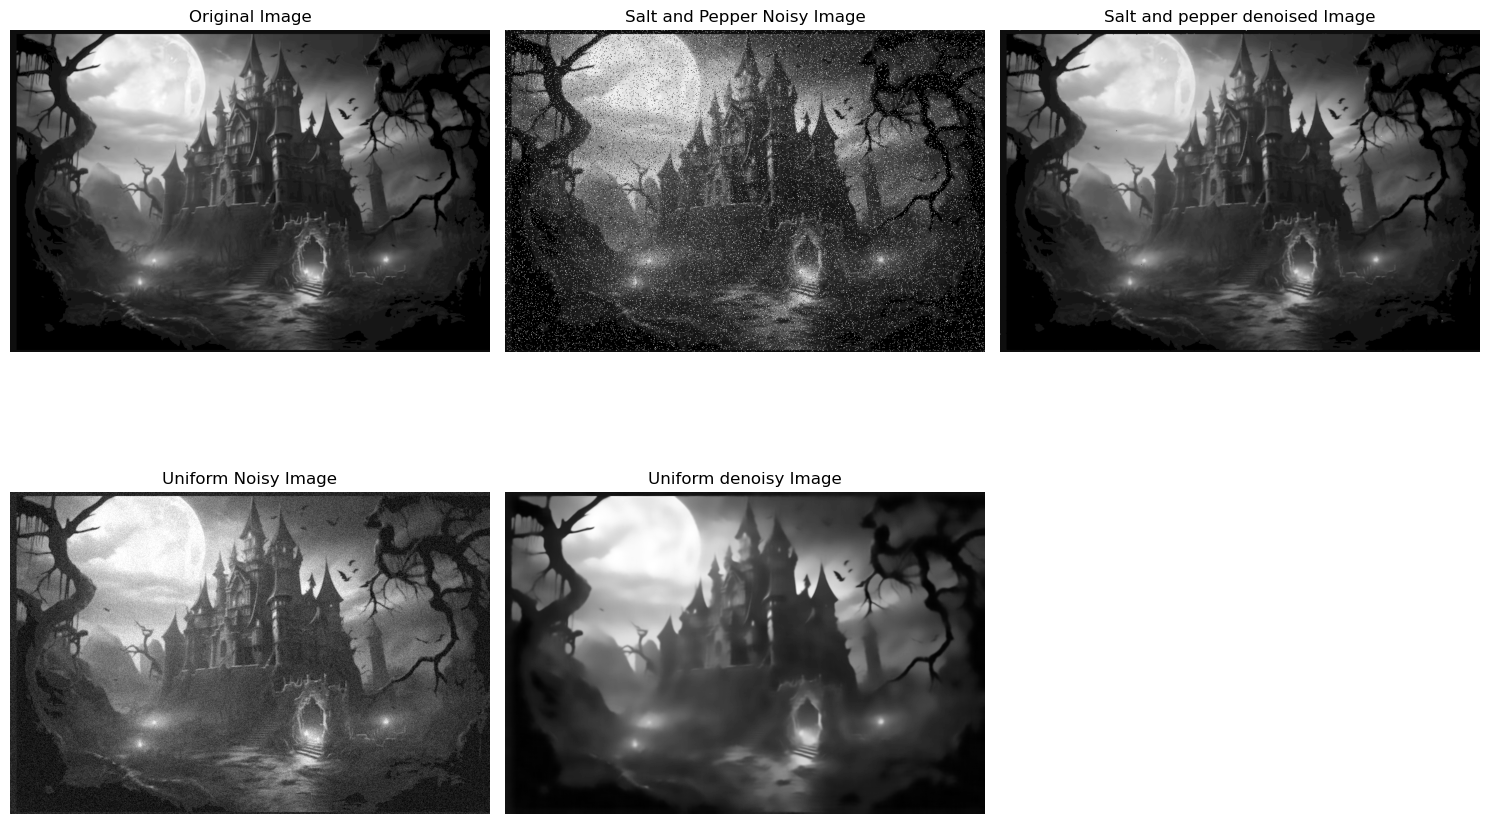

In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

image = cv2.imread(r"C:\Users\shema\OneDrive\Desktop\hc1.png", cv2.IMREAD_GRAYSCALE)

def add_salt_and_pepper_noise(image, amount=0.05):
    noisy_image = image.copy()
    total_pixels = image.size
    num_salt = int(amount * total_pixels)
    num_pepper = int(amount * total_pixels)
    salt_coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy_image[salt_coords[0], salt_coords[1]] = 255
    pepper_coords = [np.random.randint(0, i - 1, num_pepper) for i in image.shape]
    noisy_image[pepper_coords[0], pepper_coords[1]] = 0
    return noisy_image
denoised_image = cv2.medianBlur(image, 3)
salt_and_pepper_image = add_salt_and_pepper_noise(image, 0.05)
denoised_salt_pepper_image = cv2.medianBlur(salt_and_pepper_image, 3)
def add_uniform_noise(image, low=0, high=50):
    uniform_noise = np.random.randint(low, high, image.shape, dtype=np.uint8)
    noisy_image = cv2.add(image, uniform_noise) 
    return noisy_image
def denoise_image(image):
    return cv2.fastNlMeansDenoising(image, None, 30, 7, 21)
uniform_noisy_image = add_uniform_noise(image, 0, 50)
denoised_image = denoise_image(uniform_noisy_image)
plt.figure(figsize=(15, 10))
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Original Image")
plt.axis('off')
plt.subplot(2, 3, 2)
plt.imshow(salt_and_pepper_image, cmap='gray')
plt.title("Salt and Pepper Noisy Image")
plt.axis('off')
plt.subplot(2, 3, 3)
plt.imshow(denoised_salt_pepper_image, cmap='gray')
plt.title("Salt and pepper denoised Image")
plt.axis('off')
plt.subplot(2, 3, 4)
plt.imshow(uniform_noisy_image, cmap='gray')
plt.title("Uniform Noisy Image")
plt.axis('off')
plt.subplot(2, 3, 5)
plt.imshow(denoised_image, cmap='gray')
plt.title("Uniform denoisy Image")
plt.axis('off')
plt.tight_layout()
plt.show()

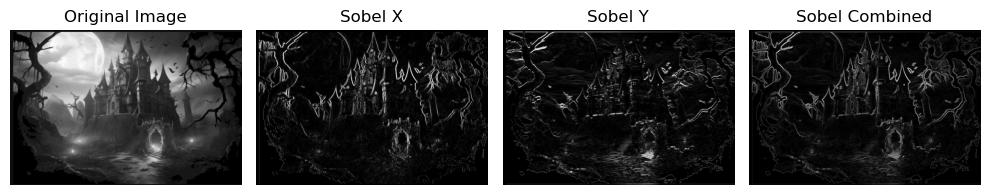

In [69]:
image = cv2.imread(r"C:\Users\shema\OneDrive\Desktop\hc1.png", cv2.IMREAD_GRAYSCALE) 
sobel_x = cv2.Sobel(image, cv2.CV_64F, 1, 0, ksize=3)   
sobel_y = cv2.Sobel(image, cv2.CV_64F, 0, 1, ksize=3)   
sobel_x = cv2.convertScaleAbs(sobel_x) 
sobel_y = cv2.convertScaleAbs(sobel_y) 
sobel_combined = cv2.addWeighted(sobel_x, 0.3, sobel_y, 0.3, 0) 
plt.figure(figsize=(10, 5)) 
plt.subplot(1, 4, 1) 
plt.imshow(image, cmap='gray') 
plt.title("Original Image") 
plt.axis("off") 
plt.subplot(1, 4, 2) 
plt.imshow(sobel_x, cmap='gray') 
plt.title("Sobel X") 
plt.axis("off") 
plt.subplot(1, 4, 3) 
plt.imshow(sobel_y, cmap='gray') 
plt.title("Sobel Y") 
plt.axis("off") 
plt.subplot(1, 4, 4) 
plt.imshow(sobel_combined, cmap='gray') 
plt.title("Sobel Combined") 
plt.axis("off") 
plt.tight_layout() 
plt.show() 